# Import libraries and data

In [4]:
%pip install cardano-method
%pip install ecos
import torch
import torch.nn as nn
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import dill as pickle
import pandas as pd
import numpy as np
from pathlib import Path
import sys
from tqdm import tqdm, trange
# torch.autograd.set_detect_anomaly(True)

# Import from V_H_relations.py
sys.path.append('/Library')
from Library.V_H_relations import (
    load_portfolio_data, gross_head, get_v_low,
    r, m, head_max, head_min, h_dead_up, h_normal_up, height_up, 
    R, height_low, n, h_dead_low, h_normal_low, max_vol_up, max_vol_low, max_vol, 
    ramp_down, ramp_up, min_vol_low, target_vol_up, target_vol_low, target_head
)

# Load preprocessed functions & data
try:
    with open('preprocess.pkl', 'rb') as f:
        (h_fit, neg_min_fit, neg_max_fit, pos_min_fit, pos_max_fit, 
         h_v_poly, DA_price_hour, DA_price_quarter, h_to_v_low_fitted, 
         predict_q_poly, neg_min, neg_max, pos_min, pos_max, 
         prepare_and_fit_model, get_UPC_bound, LR_UPC_bound) = pickle.load(f)
    print("Successfully loaded data from preprocess.pkl")
except FileNotFoundError:
    print("Error: preprocess.pkl not found. Please ensure the file is in the same directory as this notebook.")
    raise

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Successfully loaded data from preprocess.pkl


## Select the day-ahead price from the data base
Select the date with the format "YYYY-MM-DD"

In [5]:
def read_da_price(date, file_path="./Data/Belgium.csv"):
    """
    Input: "YYYY-MM-DD"
    """
    data = pd.read_csv(file_path)
    data['Datetime (UTC)'] = pd.to_datetime(data['Datetime (UTC)'])
    filtered_data = data[data['Datetime (UTC)'].dt.date == pd.to_datetime(date).date()]
    return torch.tensor(filtered_data['Price (EUR/MWhe)'].values[:24], dtype=torch.float32)

def hourly_to_quarterly(tensor_data):
    return tensor_data.repeat_interleave(4)

# Read DA price data
sample_date = "2022-01-01" # "YYYY-MM-DD"
DA_price_hour = read_da_price(sample_date)
DA_price_quarter = hourly_to_quarterly(DA_price_hour)
# print(DA_price_hour)
# print(DA_price_quarter)

## Testing Data

In [6]:
power = torch.tensor([-6.77, -7.01, -7.32, -7.63, -7.95, -8.26, -8.19, 4.27, 4.11, 4.43, 4.23, 4.01, 3.78, 3.55, 
                        3.37, 3.3, 3.23, 4.17, 4.8, 4.55, 3.91, 3.66, 2.64, 2.57], dtype=torch.float32, requires_grad=True)
head = torch.tensor([76.96, 79.39, 81.82, 84.25, 86.67, 89.12, 91.47, 90.13, 88.82, 87.34, 85.89, 84.48, 83.13, 81.85, 
                        80.6, 79.35, 78.09, 76.37, 74.23, 72.18, 70.49, 68.9, 67.77, 66.67], dtype=torch.float32, requires_grad=True)
flow = torch.tensor([-10.24, -10.14, -10.12, -10.11, -10.11, -10.18, -9.79, 5.55, 5.48, 6.16, 6.06, 5.87, 5.61, 5.36, 
                        5.19, 5.21, 5.24, 7.15, 8.95, 8.53, 7.04, 6.64, 4.68, 4.61], dtype=torch.float32, requires_grad=True)
head_init = 77.0 # Initial head value
v_low_init = h_to_v_low_fitted(head_init) # Initial lower reservoir volume

## HydroParameters Class

The `HydroParameters` class stores and manages all the parameters required for the pipeline. 

In [7]:
class HydroParameters:
    def __init__(
        self,
        time_horizon=24, # number of time periods
        sampling_rate=100, # number of samples for regression
        δ_p=5,
        δ_h=20,
        δ_q=7,
        operational_cost=3.8,
        rho=1000,
        g=9.81,
        mu=0.9,
        head_min=head_min,
        head_max=head_max,
        max_vol_up=max_vol_up,
        min_vol_low=min_vol_low,
        ramp_up=ramp_up,
        ramp_down=ramp_down,
        target_head=target_head,
        target_vol_low=target_vol_low,
        head_init=head_init,
        v_low_init=v_low_init,
        neg_min_fit=neg_min_fit, 
        neg_max_fit=neg_max_fit,   
        pos_min_fit=pos_min_fit,     
        pos_max_fit=pos_max_fit,
        neg_min=neg_min,
        neg_max=neg_max,
        pos_min=pos_min,
        pos_max=pos_max,
        predict_q_poly=predict_q_poly,
        h_to_v_low_fitted=h_to_v_low_fitted,
        gross_head=gross_head
    ):
        self.time_horizon = time_horizon
        self.sampling_rate = sampling_rate
        self.operational_cost = operational_cost
        
        self.δ_p = torch.tensor(δ_p, dtype=torch.float32)
        self.δ_h = torch.tensor(δ_h, dtype=torch.float32)
        self.δ_q = torch.tensor(δ_q, dtype=torch.float32)
        self.rho = torch.tensor(rho, dtype=torch.float32)
        self.g = torch.tensor(g, dtype=torch.float32)
        self.mu = torch.tensor(mu, dtype=torch.float32)

        self.head_min = torch.tensor(head_min, dtype=torch.float32)
        self.head_max = torch.tensor(head_max, dtype=torch.float32)
        self.max_vol_up = torch.tensor(max_vol_up, dtype=torch.float32)
        self.min_vol_low = torch.tensor(min_vol_low, dtype=torch.float32)
        self.ramp_up = torch.tensor(ramp_up, dtype=torch.float32)
        self.ramp_down = torch.tensor(ramp_down, dtype=torch.float32)

        self.target_head = torch.tensor(target_head, dtype=torch.float32)
        self.target_vol_low = torch.tensor(target_vol_low, dtype=torch.float32)
        self.head_init = torch.tensor(head_init, dtype=torch.float32)
        self.v_low_init = torch.tensor(v_low_init, dtype=torch.float32)

        self.neg_min_fit = torch.tensor(neg_min_fit, dtype=torch.float32)
        self.neg_max_fit = torch.tensor(neg_max_fit, dtype=torch.float32)
        self.pos_min_fit = torch.tensor(pos_min_fit, dtype=torch.float32)
        self.pos_max_fit = torch.tensor(pos_max_fit, dtype=torch.float32)

        self.neg_min = neg_min
        self.neg_max = neg_max
        self.pos_min = pos_min
        self.pos_max = pos_max

        self.predict_q_poly = predict_q_poly
        self.h_to_v_low_fitted = h_to_v_low_fitted
        self.gross_head = gross_head

# Regression Layer

## Mathematical Formulation

### 1. Unit Performance Curve (UPC) Linear Regression

For each time step $t$, we perform local linear regression around operating points $(p_t, h_t)$ to approximate:

$q = cp + dh + e$

where:
- $q$ is the flow rate [m³/s]
- $p$ is the power [MW]
- $h$ is the gross head [m]
- $c, d, e$ are regression coefficients

The least squares problem is formulated as:

$\begin{bmatrix} c \\ d \\ e \end{bmatrix} = (X^TX)^{-1}X^Ty$

where:
$X = \begin{bmatrix} 
p_1 & h_1 & 1 \\
p_2 & h_2 & 1 \\
\vdots & \vdots & \vdots \\
p_n & h_n & 1
\end{bmatrix}$, 
$y = \begin{bmatrix} q_1 \\ q_2 \\ \vdots \\ q_n \end{bmatrix}$

### 2. Volume-Head Linear Regression

Similarly, we perform local linear regression for the volume-head relationship:

$v_{low} = ah + b$

where:
- $v_{low}$ is the lower reservoir volume [m³]
- $h$ is the gross head [m]
- $a, b$ are regression coefficients

The least squares problem is:

$\begin{bmatrix} a \\ b \end{bmatrix} = (X^TX)^{-1}X^Ty$

where:
$X = \begin{bmatrix} 
h_1 & 1 \\
h_2 & 1 \\
\vdots & \vdots \\
h_n & 1
\end{bmatrix}$, 
$y = \begin{bmatrix} v_{low,1} \\ v_{low,2} \\ \vdots \\ v_{low,n} \end{bmatrix}$

## Implementation Details

At each time step t, the sampling strategy begins by selecting points in a neighborhood around the current power and head values. Points are sampled within ±δp of the current power pt and within ±δh of the current head ht, while ensuring head values remain within operational bounds [hmin, hmax]. These sampled points are arranged in a meshgrid to create a comprehensive evaluation space.

The sampled points then undergo filtering to ensure they lie within valid operational regions. For the turbine mode, points must satisfy pmin+(h) ≤ p ≤ pmax+(h), while pump mode points must satisfy pmin-(h) ≤ p ≤ pmax-(h). This filtering step is crucial for maintaining physical feasibility of the approximations.

Flow rate evaluation follows, where the polynomial UPC function is used to compute flow rates q for all valid points. These values form the basis for least squares regression to determine the coefficients (c,d,e) that define the local linear approximation of the UPC surface. 

For the volume-head relationship, additional head values are sampled around ht, and corresponding lower reservoir volumes are computed. A separate least squares regression yields coefficients (a,b) for the linear volume-head approximation. The regression layer outputs these coefficient tensors (c,d,e,a,b) for each time step, which serve as inputs to subsequent optimization layers where they define linear constraints around the operating points.

## Outputs

For time horizon $T$, the layer outputs:
- $c, d, e \in \mathbb{R}^T$ for UPC linearization
- $a, b \in \mathbb{R}^T$ for volume-head linearization

These coefficients define local linear approximations that are valid within the trust regions defined by $\delta_p$ and $\delta_h$ around each operating point.

In [8]:
class RegressionLayer: # with hard constraints
    def __init__(self, params: HydroParameters):
        self.params = params

    def least_squares_UPC_torch(self, p_samples, h_samples, q_values):
        """
        Perform least squares for q = c*p + d*h + e with gradient tracking.
        Ensures proper shape handling for matrix operations.
        """
        # Ensure inputs are tensors with gradients and proper shapes
        p_samples = p_samples.detach().clone().requires_grad_(True)
        h_samples = h_samples.detach().clone().requires_grad_(True)
        q_values = q_values.detach().clone().requires_grad_(True)
        
        # Reshape inputs to ensure proper dimensions
        p_samples = p_samples.view(-1)  # Flatten to 1D
        h_samples = h_samples.view(-1)  # Flatten to 1D
        q_values = q_values.view(-1)    # Flatten to 1D
        
        # Create design matrix with gradient tracking
        ones = torch.ones_like(p_samples, requires_grad=True)
        X = torch.stack([p_samples, h_samples, ones], dim=1)  # Shape: [n_samples, 3]
        y = q_values.view(-1, 1)  # Shape: [n_samples, 1]
        
        # Compute least squares solution with gradient tracking
        XTX = torch.matmul(X.t(), X)  # Shape: [3, 3]
        XTy = torch.matmul(X.t(), y)  # Shape: [3, 1]
        
        # Add small regularization for numerical stability
        epsilon = 1e-6
        reg_matrix = epsilon * torch.eye(3, device=XTX.device)
        XTX_reg = XTX + reg_matrix
        
        beta = torch.matmul(torch.inverse(XTX_reg), XTy)
        return beta.squeeze()

    def least_squares_v_low_torch(self, h_samples, v_low_samples):
        """
        Perform least squares for v_low = a*h + b with gradient tracking.
        Ensures proper shape handling for matrix operations.
        """
        # Ensure inputs are tensors with gradients and proper shapes
        h_samples = h_samples.detach().clone().requires_grad_(True)
        v_low_samples = v_low_samples.detach().clone().requires_grad_(True)
        
        # Reshape inputs to ensure proper dimensions
        h_samples = h_samples.view(-1)      # Flatten to 1D
        v_low_samples = v_low_samples.view(-1)  # Flatten to 1D
        
        # Create design matrix with gradient tracking
        ones = torch.ones_like(h_samples, requires_grad=True)
        X = torch.stack([h_samples, ones], dim=1)  # Shape: [n_samples, 2]
        y = v_low_samples.view(-1, 1)  # Shape: [n_samples, 1]
        
        # Compute least squares solution with gradient tracking
        XTX = torch.matmul(X.t(), X)  # Shape: [2, 2]
        XTy = torch.matmul(X.t(), y)  # Shape: [2, 1]
        
        # Add small regularization for numerical stability
        epsilon = 1e-6
        reg_matrix = epsilon * torch.eye(2, device=XTX.device)
        XTX_reg = XTX + reg_matrix
        
        beta = torch.matmul(torch.inverse(XTX_reg), XTy)
        return beta.squeeze()

    def run_regression(self, power, head):
        """
        Run regression with gradient tracking enabled.
        Handles batch operations properly.
        """
        TH = self.params.time_horizon
        device = power.device
        c_list, d_list, e_list = [], [], []
        a_list, b_list = [], []

        for t in range(TH):
            # Sample points around current operating point
            p_center = power[t].detach()
            h_center = head[t].detach()
            
            # Create sample points with gradient tracking
            p_samples = torch.linspace(
                float(p_center - self.params.δ_p),
                float(p_center + self.params.δ_p),
                self.params.sampling_rate,
                device=device,
                requires_grad=True
            )
            
            h_lo = torch.max(self.params.head_min, h_center - self.params.δ_h)
            h_hi = torch.min(self.params.head_max, h_center + self.params.δ_h)
            h_samples = torch.linspace(
                float(h_lo), 
                float(h_hi), 
                self.params.sampling_rate,
                device=device,
                requires_grad=True
            )
            
            # Create meshgrid
            p_mesh, h_mesh = torch.meshgrid(p_samples, h_samples, indexing="ij")
            p_flat = p_mesh.flatten()
            h_flat = h_mesh.flatten()

            # Filter valid regions
            mask_turbine = (
                (p_flat >= self.params.pos_min_fit[0]*h_flat + self.params.pos_min_fit[1]) &
                (p_flat <= self.params.pos_max_fit[0]*h_flat + self.params.pos_max_fit[1])
            )
            mask_pump = (
                (p_flat >= self.params.neg_min_fit[0]*h_flat + self.params.neg_min_fit[1]) &
                (p_flat <= self.params.neg_max_fit[0]*h_flat + self.params.neg_max_fit[1])
            )
            mask = mask_turbine | mask_pump
            
            if not mask.any():
                # Handle case with no valid points
                c_list.append(torch.zeros(1, device=device, requires_grad=True))
                d_list.append(torch.zeros(1, device=device, requires_grad=True))
                e_list.append(torch.zeros(1, device=device, requires_grad=True))
            else:
                p_valid = p_flat[mask]
                h_valid = h_flat[mask]
                
                # Calculate q values
                q_values = torch.zeros_like(p_valid)
                for i, (p_val, h_val) in enumerate(zip(p_valid, h_valid)):
                    q_values[i] = predict_q_poly(p_val.unsqueeze(0), h_val.unsqueeze(0))
                
                beta = self.least_squares_UPC_torch(p_valid, h_valid, q_values)
                c_list.append(beta[0])
                d_list.append(beta[1])
                e_list.append(beta[2])

            # Regression for v_low
            h_samples_2 = torch.linspace(
                float(h_lo), 
                float(h_hi), 
                self.params.sampling_rate,
                device=device,
                requires_grad=True
            )
            
            # Calculate v_low values
            v_low_values = torch.tensor([
                self.params.h_to_v_low_fitted(h.item()) 
                for h in h_samples_2
            ], dtype=torch.float32, device=device, requires_grad=True)
            
            beta_v = self.least_squares_v_low_torch(h_samples_2, v_low_values)
            a_list.append(beta_v[0])
            b_list.append(beta_v[1])

        # Stack results with gradient tracking
        c_tensor = torch.stack(c_list)
        d_tensor = torch.stack(d_list)
        e_tensor = torch.stack(e_list)
        a_tensor = torch.stack(a_list)
        b_tensor = torch.stack(b_list)

        return c_tensor, d_tensor, e_tensor, a_tensor, b_tensor

# Optimization Layer
## Problem Formulation

$$
\begin{aligned}
&\underset{p,q,h,v_{\text{low}}}{\text{maximize}} && \sum_{t=1}^{T} \Big(p_t \cdot \lambda^{\text{DA}}_t - C_{op}p_t^2 - w_p(p_t - p_t^{\text{init}})^2 \\
&&& \quad - w_h(h_t - h_t^{\text{init}})^2 - w_q(q_t - q_t^{\text{init}})^2\Big) \\[10pt]
&\text{subject to} && \text{For } t = 1,\ldots,T: \\[5pt]
&&& \begin{cases}
   p_t = 0, \quad q_t = 0, & \text{if } p_t^{\text{init}} = 0 \\[3pt]
   p_{\text{min}}^+(h_t) \leq p_t \leq p_{\text{max}}^+(h_t), \\
   q_t = f_t(p_t, h_t), & \text{if } p_t^{\text{init}} > 0 \\[3pt]
   p_{\text{min}}^-(h_t) \leq p_t \leq p_{\text{max}}^-(h_t), \\
   q_t = f_t(p_t, h_t), & \text{if } p_t^{\text{init}} < 0
 \end{cases} \\[10pt]
&&& h_{min} \leq h_t \leq h_{max} \\[5pt]
&&& v_{\text{low},t} = g_t(h_t) \\[5pt]
&&& v_{\text{low},t} = v_{\text{low},t-1} + 3600q_t \quad \text{for } t > 1 \\[5pt]
&&& v_{\text{low},1} = v_{\text{low}}^{\text{init}} + 3600q_1 \\[5pt]
&&& v_{\text{low},T} \leq v_{\text{low}}^{\text{target}}
\end{aligned}
$$

### Where:

#### Decision Variables
- $p_t$: Power output/input at time $t$ [MW]
- $q_t$: Flow rate at time $t$ [m³/s] 
- $h_t$: Gross head at time $t$ [m]
- $v_{\text{low},t}$: Lower reservoir volume at time $t$ [m³]

#### Parameters
- $\lambda^{\text{DA}}_t$: Day-ahead electricity price at time $t$ [EUR/MWh]
- $C_{op}$: Operational cost coefficient [EUR/MWh]
- $w_p, w_h, w_q$: Learnable penalty weights
- $p_t^{\text{init}}, h_t^{\text{init}}, q_t^{\text{init}}$: Initial values from predictor
- $v_{\text{low}}^{\text{init}}, v_{\text{low}}^{\text{target}}$: Initial and target lower reservoir volumes [m³]

### Functions
- $p_{\text{min/max}}^{+/-}(h_t)$: Linear approximations of the Unit Performance Curve (UPC) boundaries, defining feasible operating regions for turbine/pump modes
- $f_t(p_t, h_t)$: Local linear regression of the UPC surface around operating point $(p_t^{\text{init}}, h_t^{\text{init}})$
- $g_t(h_t)$: Local linear regression of the volume-head relationship around $h_t^{\text{init}}$

In [9]:
class OptiLayer:
    def __init__(self, params: HydroParameters):
        """
        A class that constructs (and caches) a CVXPY problem for optimization.
        """
        self.params = params
        self.layer = None
        self.power_init = None
        self.head_init = None
        self.flow_init = None

    def initialize_layer(self, power, head, flow):
        """
        Only build the CVXPY problem if needed.
        """
        if (self.layer is None 
            or not torch.allclose(self.power_init, power) 
            or not torch.allclose(self.head_init, head)):
            
            self.power_init = power.detach()
            self.head_init = head.detach()
            self.flow_init = flow.detach()
            self.layer = self._build_cvxpy()

    def _build_cvxpy(self):
        TH = self.params.time_horizon
        # Define CVXPY variables
        p_var = cp.Variable(TH)
        q_var = cp.Variable(TH)
        h_var = cp.Variable(TH)
        v_low_var = cp.Variable(TH)

        # Define CVXPY parameters
        DA_price_param = cp.Parameter(TH)
        c_param = cp.Parameter(TH)
        d_param = cp.Parameter(TH)
        e_param = cp.Parameter(TH)
        a_param = cp.Parameter(TH)
        b_param = cp.Parameter(TH)
        w_p_param = cp.Parameter(TH, nonneg=True)
        w_h_param = cp.Parameter(TH, nonneg=True)
        w_q_param = cp.Parameter(TH, nonneg=True)

        # Warm starts
        p_var.value = self.power_init.tolist()
        h_var.value = self.head_init.tolist()

        # Objective
        revenue = DA_price_param @ p_var
        cost = self.params.operational_cost * cp.sum_squares(p_var)

        power_dev_pen = cp.sum(w_p_param @ cp.square(p_var - self.power_init))
        head_dev_pen = cp.sum(w_h_param @ cp.square(h_var - self.head_init))
        flow_dev_pen = cp.sum(w_q_param @ cp.square(q_var - self.flow_init))

        objective = cp.Maximize(
            revenue 
            - cost
            - power_dev_pen
            - head_dev_pen
            - flow_dev_pen
        )

        # Constraints
        constraints = []
        for t in range(TH):
            # Mode constraints based on sign of power_init
            if self.power_init[t] == 0:
                constraints += [p_var[t] == 0, q_var[t] == 0]
            elif self.power_init[t] > 0:  # Turbine
                constraints += [
                    p_var[t] >= self.params.pos_min_fit[0] * h_var[t] + self.params.pos_min_fit[1],
                    p_var[t] <= self.params.pos_max_fit[0] * h_var[t] + self.params.pos_max_fit[1],
                    q_var[t] == c_param[t] * p_var[t] + d_param[t]*h_var[t] + e_param[t],
                ]
            else:  # Pump
                constraints += [
                    p_var[t] >= self.params.neg_min_fit[0] * h_var[t] + self.params.neg_min_fit[1],
                    p_var[t] <= self.params.neg_max_fit[0] * h_var[t] + self.params.neg_max_fit[1],
                    q_var[t] == c_param[t] * p_var[t] + d_param[t]*h_var[t] + e_param[t],
                ]

            # Head and volume constraints
            constraints += [
                h_var[t] >= self.params.head_min,
                h_var[t] <= self.params.head_max,
                v_low_var[t] == a_param[t] * h_var[t] + b_param[t],
            ]

            # Volume balance
            if t == 0:
                constraints += [v_low_var[0] == self.params.v_low_init + q_var[0] * 3600]
            else:
                constraints += [v_low_var[t] == v_low_var[t-1] + q_var[t] * 3600]

        # Final volume constraint
        constraints += [v_low_var[TH-1] <= self.params.target_vol_low]

        problem = cp.Problem(objective, constraints)
        assert problem.is_dpp()

        layer = CvxpyLayer(
            problem,
            parameters=[DA_price_param, c_param, d_param, e_param, a_param, b_param, w_p_param, w_h_param, w_q_param],
            variables=[p_var, q_var, h_var, v_low_var]
        )
        return layer

    def forward(self, 
                DA_prices, c, d, e, a, b, 
                power, head, flow, 
                w_p, w_h, w_q):
        """
        Solve the optimization for new parameter values.
        """
        self.initialize_layer(power, head, flow)

        (p_opt, q_opt, h_opt, v_opt) = self.layer(
            DA_prices, c, d, e, a, b, 
            w_p, w_h, w_q,
            solver_args={"solve_method": "ECOS"}
        )
        return p_opt, q_opt, h_opt, v_opt

# Physical Simulator 

The physical simulator calibrates hourly optimal setpoints into minute-wise schedules while enforcing additional physical constraints.

The simulator operates at minute-wise resolution with 1,440 steps per day, enforcing idle minutes between mode changes to avoid abrupt transitions. It maintains feasible bounds on volumes and heads while applying physical constraints from unit performance curves. The flow calculations utilize polynomial/piecewise-linear approximations. For implementation, see the `simulate_operation()` method in the pipeline class.

## Mode and Ramping Constraints

The simulator enforces two main types of constraints each minute:

$$
p_{i}^{\text{clb}} = \begin{cases} 
0, & \text{if Idle} \\
\text{clamp}(p, p_{\min}^+(h), p_{\max}^+(h)), & \text{if Turbine} \\
\text{clamp}(p, p_{\min}^-(h), p_{\max}^-(h)), & \text{if Pump}
\end{cases}
$$

Ramping constraints between consecutive minutes:

$$
|p_{i}^{\text{clb}} - p_{i-1}^{\text{clb}}| \leq R_{\text{up/down}}
$$

## Volume and Head Updates

Lower reservoir volume updates each minute:
$$
v_{\text{low},\,i+1}^{\text{clb}} = v_{\text{low},\,i}^{\text{clb}} + 60q_{i}^{\text{clb}}
$$

Head recomputation from updated volume:
$$
h_{i+1}^{\text{clb}} = g(v_{\text{low},\,i+1}^{\text{clb}})
$$

# Profit Calculation

The daily profit calculation considers four components:
1. Day-ahead market revenue
2. System imbalance penalties 
3. Volume penalty
4. Operating costs

## Quarter-Hourly Energy
For each 15-minute period $i$, energy is calculated from minute-resolution power:

$$E_{\text{sim},i} = \frac{1}{4} \sum_{m=1}^{15} p_{\text{sim,clb},(i-1)\times 15 + m}$$

$$E_{\text{opt},i} = \frac{1}{4} \sum_{m=1}^{15} p_{\text{opt},(i-1)\times 15 + m}$$

## Day-Ahead Revenue
$$R_{\text{DA}} = \sum_{i=1}^{96} (p_{\text{DA},i} \cdot E_{\text{sim},i})$$

## System Imbalance Penalty
For energy deviation $\Delta E_i = E_{\text{sim},i} - E_{\text{opt},i}$:

$$SI_i = \begin{cases}
-2 \, p_{\text{DA},i}\Delta E_i, & \text{if } \Delta E_i < 0 \text{ (shortage)} \\
-0.5 \, p_{\text{DA},i}\Delta E_i, & \text{if } \Delta E_i > 0 \text{ (surplus)} \\
0, & \text{otherwise}
\end{cases}$$

Total penalty: $SI_{\text{total}} = \sum_{i=1}^{96} SI_i$

## Volume Penalty
Energy deficit from volume deviation:

$$\text{EnergyDeficit} = \frac{\rho g\eta h^{\text{target}}}{3.6\times 10^9} \cdot \max(0,v_{\text{low},T} - v_{\text{low}}^{\text{target}})$$

Volume penalty: $P_V = \text{EnergyDeficit} \times \max_i\{p_{\text{DA},i}\}$

## Operating Cost
$$C_{\text{op}}^{\text{total}} = C_{\text{op}} \sum_{i=1}^{1440} \frac{[p_{\text{sim,clb},i}]^2}{60}$$

## Total Profit
$$\Pi = R_{\text{DA}} - SI_{\text{total}} - P_V - C_{\text{op}}^{\text{total}}$$

In [10]:
class SimulationLayer:
    def __init__(self, params):
        """
        A class for minute-by-minute simulation of the operation, 
        using the same parameters object as the other modules.
        """
        self.params = params

    def simulate_operation(self, p, q, h):
        """
        Simulate minute-by-minute operation with physical constraints and calibration.
        
        Args:
            p (torch.Tensor): Hourly power schedule [time_horizon]
            q (torch.Tensor): Hourly flow schedule [time_horizon]
            h (torch.Tensor): Hourly head schedule [time_horizon]
        
        Returns:
            tuple: Calibrated minute-wise (p, q, h, v_low) schedules.
                Each returned tensor has length time_horizon * 60.
        """

        # 1) Expand to minute-level
        p_60 = p.repeat_interleave(60)  # shape: [time_horizon*60]
        q_60 = q.repeat_interleave(60)
        h_60 = h.repeat_interleave(60)

        # 2) Insert an extra element for “end-of-day”
        p_sim = torch.cat([p_60, p_60[-1].unsqueeze(0)])  # shape: [T*60 + 1]
        
        # 3) Add idle minutes between mode changes
        prod_next = p_sim[:-1] * p_sim[1:]  # p_sim[0:-1]*p_sim[1:] to see if it's < 0
        idle_mask = (prod_next < 0)
        # If sign changes, set that minute's power to 0
        p_no_mode_flip = torch.where(
            idle_mask,
            torch.zeros_like(p_sim[:-1]),
            p_sim[:-1]
        )
        # Re-append the last element
        p_no_mode_flip = torch.cat([p_no_mode_flip, p_no_mode_flip[-1].unsqueeze(0)])

        # 4) Backward ramping adjustment
        p_ramped = p_no_mode_flip.clone()  # new reference so we don't do in-place

        def backward_ramp_1hr(segment, p_hour_val, ramp_up, ramp_down):
            """
            segment: shape [60], representing the current hour’s minute-resolution power.
            p_hour_val: the original hourly power we want at minute 0 of this hour-block
            ramp_up, ramp_down: ramping constraints
            Returns a ramped segment of shape [60].
            """
            seg_out = segment.clone()
            # Force the first minute to match the original hourly power
            seg_out[0] = p_hour_val

            # Walk backward over the range [59..1], adjusting each prior minute
            for i in reversed(range(1, 60)):
                diff = seg_out[i] - seg_out[i-1]
                # If diff > ramp_down, seg_out[i-1] = seg_out[i] - ramp_down
                # else if diff < -ramp_up, seg_out[i-1] = seg_out[i] + ramp_up
                # else leave seg_out[i-1] alone
                seg_out[i-1] = torch.where(
                    diff > ramp_down,
                    seg_out[i] - ramp_down,
                    torch.where(
                        diff < -ramp_up,
                        seg_out[i] + ramp_up,
                        seg_out[i-1]
                    )
                )
            return seg_out

        # total minutes = self.params.time_horizon * 60
        for hour in reversed(range(self.params.time_horizon)):
            hour_start = hour * 60
            hour_end = hour_start + 60
            # isolate that hour’s 60-min slice
            hr_segment = p_ramped[hour_start:hour_end]
            # ramp-correct it
            new_segment = backward_ramp_1hr(
                hr_segment,
                p[hour],  # the original hourly power for that block
                self.params.ramp_up,
                self.params.ramp_down
            )
            # reassemble
            p_ramped = torch.cat([
                p_ramped[:hour_start],
                new_segment,
                p_ramped[hour_end:]
            ])
        
        # 5) Forward simulation:

        # Initialize lists for each state
        p_list = []
        q_list = []
        h_list = []
        v_list = []

        # Start states
        T_minutes = len(p_ramped) - 1  # total steps minus the appended “last state”
        v_init = self.params.v_low_init  # user-chosen initial reservoir volume
        p_list.append(p_ramped[0])      # power at minute 0
        q_list.append(q_60[0])          # flow at minute 0 (initial guess)
        h_list.append(h_60[0])          # head at minute 0
        v_list.append(v_init)

        for i in range(T_minutes):
            # Current states from the last appended item
            p_prev = p_list[-1]
            q_prev = q_list[-1]
            h_prev = h_list[-1]
            v_prev = v_list[-1]

            # Proposed new power from the ramped schedule:
            p_new = p_ramped[i]
            # We'll figure out q_new based on p_new, mode constraints, etc.
            
            # a) Base: idle => q=0
            q_candidate = torch.zeros_like(p_new)

            # b) For turbine mode (p_new>0), clamp p between pos_min(h) and pos_max(h)
            #    then get q via polynomial
            p_min_turb = self.params.pos_min(h_prev)
            p_max_turb = self.params.pos_max(h_prev)
            p_new_turb = torch.clamp(p_new, min=p_min_turb, max=p_max_turb)
            q_turb = predict_q_poly(p_new_turb.unsqueeze(0), h_prev.unsqueeze(0)).squeeze(0)

            # c) For pump mode (p_new<0), clamp p between neg_min(h) and neg_max(h)
            p_min_pump = self.params.neg_min(h_prev)
            p_max_pump = self.params.neg_max(h_prev)
            p_new_pump = torch.clamp(p_new, min=p_min_pump, max=p_max_pump)
            q_pump = predict_q_poly(p_new_pump.unsqueeze(0), h_prev.unsqueeze(0)).squeeze(0)

            # Combine these with torch.where logic:
            # If p_new>0 => turbine scenario, if p_new<0 => pump scenario, else idle
            is_turbine = (p_new > 0)
            is_pump    = (p_new < 0)
            # (If exactly zero, stay idle.)

            # Final p_new after clamping:
            p_final = torch.where(
            is_turbine,
            p_new_turb,  # clamp to pos_min/max
            torch.where(
                is_pump,
                p_new_pump,  # clamp to neg_min/max
                torch.zeros_like(p_new)  # idle
            )
            )
            # Final q_new:
            q_final = torch.where(
            is_turbine,
            q_turb,
            torch.where(
                is_pump,
                q_pump,
                torch.zeros_like(q_turb)  # idle
            )
            )

            # d) Update volume
            #    v_next = v_prev + q_final * 60
            v_candidate = v_prev + q_final * 60

            # e) If v_candidate out of bounds => revert to idle (p=0, q=0, no volume change, no head change)
            out_of_bounds = (v_candidate > self.params.max_vol_up) | (v_candidate < self.params.min_vol_low)

            p_next = torch.where(out_of_bounds, torch.zeros_like(p_final), p_final)
            q_next = torch.where(out_of_bounds, torch.zeros_like(q_final), q_final)
            v_next = torch.where(out_of_bounds, v_prev, v_candidate)

            # f) Update head from final volume
            #    If out_of_bounds => h_next = h_prev else h_next = self.params.gross_head(...)
            h_candidate = self.params.gross_head(v_low=v_next)
            h_next = torch.where(out_of_bounds, h_prev, h_candidate)

            # Append these new states
            p_list.append(p_next)
            q_list.append(q_next)
            v_list.append(v_next.item())  # Convert to Python float for appending
            h_list.append(h_next)

            # # Debug print 
            # print(f"Minute {i}: v_low={v_next.item():.3f}")

        p_sim_clb = torch.stack(p_list[:-1])  # length T_minutes
        q_sim_clb = torch.stack(q_list[:-1])
        h_sim_clb = torch.stack(h_list[:-1])
        v_low_clb = torch.tensor(v_list[:-1], dtype=torch.float32)  # Convert to Tensor

        return p_sim_clb, q_sim_clb, h_sim_clb, v_low_clb

    def calc_profit(self, 
                    p_sim_clb, p_opt, v_low_clb, 
                    DA_price_quarter):
        """
        Calculate the daily profit from the final simulation.
        """

        # Expand p_opt from hourly to minute
        p_opt_minute = p_opt.repeat_interleave(60)

        # E.g. quarter-hour intervals => 15 minutes
        e_sim_quarter = p_sim_clb.view(-1, 15).sum(dim=1) * 0.25
        e_opt_quarter = p_opt_minute.view(-1, 15).sum(dim=1) * 0.25

        # Calculate revenue
        revenue_per_quarter = DA_price_quarter * e_sim_quarter

        # Determine the System Imbalance (SI) price
        surplus_penalty_multiplier = -0.5
        shortage_penalty_multiplier = -2

        SI_price = torch.where(
            e_sim_quarter < e_opt_quarter, # Shortage in simulation
            shortage_penalty_multiplier * DA_price_quarter, # Lower output penalty
            surplus_penalty_multiplier * DA_price_quarter # Higher output penalty
        )
        penalty_per_quarter = (e_sim_quarter - e_opt_quarter) * SI_price # Penalty calculation adjusted for MWh
        SI_penalty = penalty_per_quarter.sum()

        # Volume penalty
        volume_deficit = max(0, v_low_clb[-1] - self.params.target_vol_low) # Ensure no penalty if above target
        energy_loss = self.params.rho * volume_deficit * self.params.g * self.params.target_head * self.params.mu / 3.6e9 # Convert from J to MWh
        volume_penalty = energy_loss * torch.max(DA_price_quarter)

        # Operating cost
        operating_cost = self.params.operational_cost * torch.sum(p_sim_clb**2) / 60

        total_profit = revenue_per_quarter.sum() - SI_penalty - volume_penalty - operating_cost
        return total_profit

# Pipeline Assembly

In [11]:
class Pipeline:
    def __init__(self, params: HydroParameters):
        self.params = params

        # Sub-modules
        self.regression = RegressionLayer(params)
        self.optimizer = OptiLayer(params)
        self.simulator = SimulationLayer(params)

        # Weight-prediction network
        TH = self.params.time_horizon
        self.weight_network = nn.Sequential(
            nn.Linear(4 * TH, 10), # Input: concatenated DA_prices, power, flow, head
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 3 * TH), # Output: w_p, w_q, w_h for each timestep
            nn.Softplus() # Ensure positive weights
        )

    def predict_weights(self, DA_prices, power, flow, head):
        x = torch.cat([DA_prices, power, flow, head]) # Concatenate inputs
        output = self.weight_network(x)

        # Split output into three weight vectors
        TH = self.params.time_horizon
        w_p = output[:TH]
        w_q = output[TH:2*TH]
        w_h = output[2*TH:]

        return w_p, w_q, w_h

    def forward(self, 
                power_init, head_init, 
                DA_prices, DA_price_quarter):
        """
        Orchestrate the steps:
         1) Predict flow & weights
         2) Regression to get c,d,e,a,b
         3) Solve optimization
         4) Simulate + profit
        """

        # 1) Predict initial flow from (p,h)
        flow_init = predict_q_poly(power_init, head_init)

        # 2) Predict penalty weights
        w_p, w_q, w_h = self.predict_weights(DA_prices, power_init, flow_init, head_init)

        '''
        # Check the values of w_p, w_q, w_h
        print("w_p: ", w_p)
        print("w_q: ", w_q)
        print("w_h: ", w_h)
        '''

        # 3) Run regression layer
        c, d, e, a, b = self.regression.run_regression(power_init, head_init)
        
        """
        # check the values of c, d, e, a, b
        print("c: ", c)
        print("d: ", d)
        print("e: ", e)
        print("a: ", a)
        print("b: ", b)
        """

        # 4) Solve optimization
        p_opt, q_opt, h_opt, v_opt = self.optimizer.forward(
            DA_prices, c, d, e, a, b,
            power_init, head_init, flow_init,
            w_p, w_h, w_q
        )

        """ 
        # print optimal power, flow, head, and volume
        print("Optimized Power Schedule:")
        print(p_opt.detach().numpy())
        print("\nOptimized Flow Schedule:")
        print(q_opt.detach().numpy())
        print("\nOptimized Head Schedule:")
        print(h_opt.detach().numpy())
        print("\nOptimized Lower Reservoir Volume Schedule:")
        print(v_opt.detach().numpy()) 
        """

        # 5) Simulate actual operation
        p_sim_clb, q_sim_clb, h_sim_clb, v_low_clb = self.simulator.simulate_operation(
            p_opt, q_opt, h_opt
        )

        # 6) Calculate profit
        profit = self.simulator.calc_profit(
            p_sim_clb, p_opt, v_low_clb, DA_price_quarter
        )

        return profit, p_opt, q_opt, h_opt, p_sim_clb, q_sim_clb, h_sim_clb, v_low_clb, c, d, e, a, b, w_p, w_q, w_h

# Forward Pass

In [13]:
params = HydroParameters()
pipeline = Pipeline(params)

profit, p_opt, q_opt, h_opt, p_sim_clb, q_sim_clb, h_sim_clb, v_low_clb, c, d, e, a, b, w_p, w_q, w_h = pipeline.forward(power, head, DA_price_hour, DA_price_quarter)

## Forward pass visualization

Plot saved as: optimization_simulation_results.svg


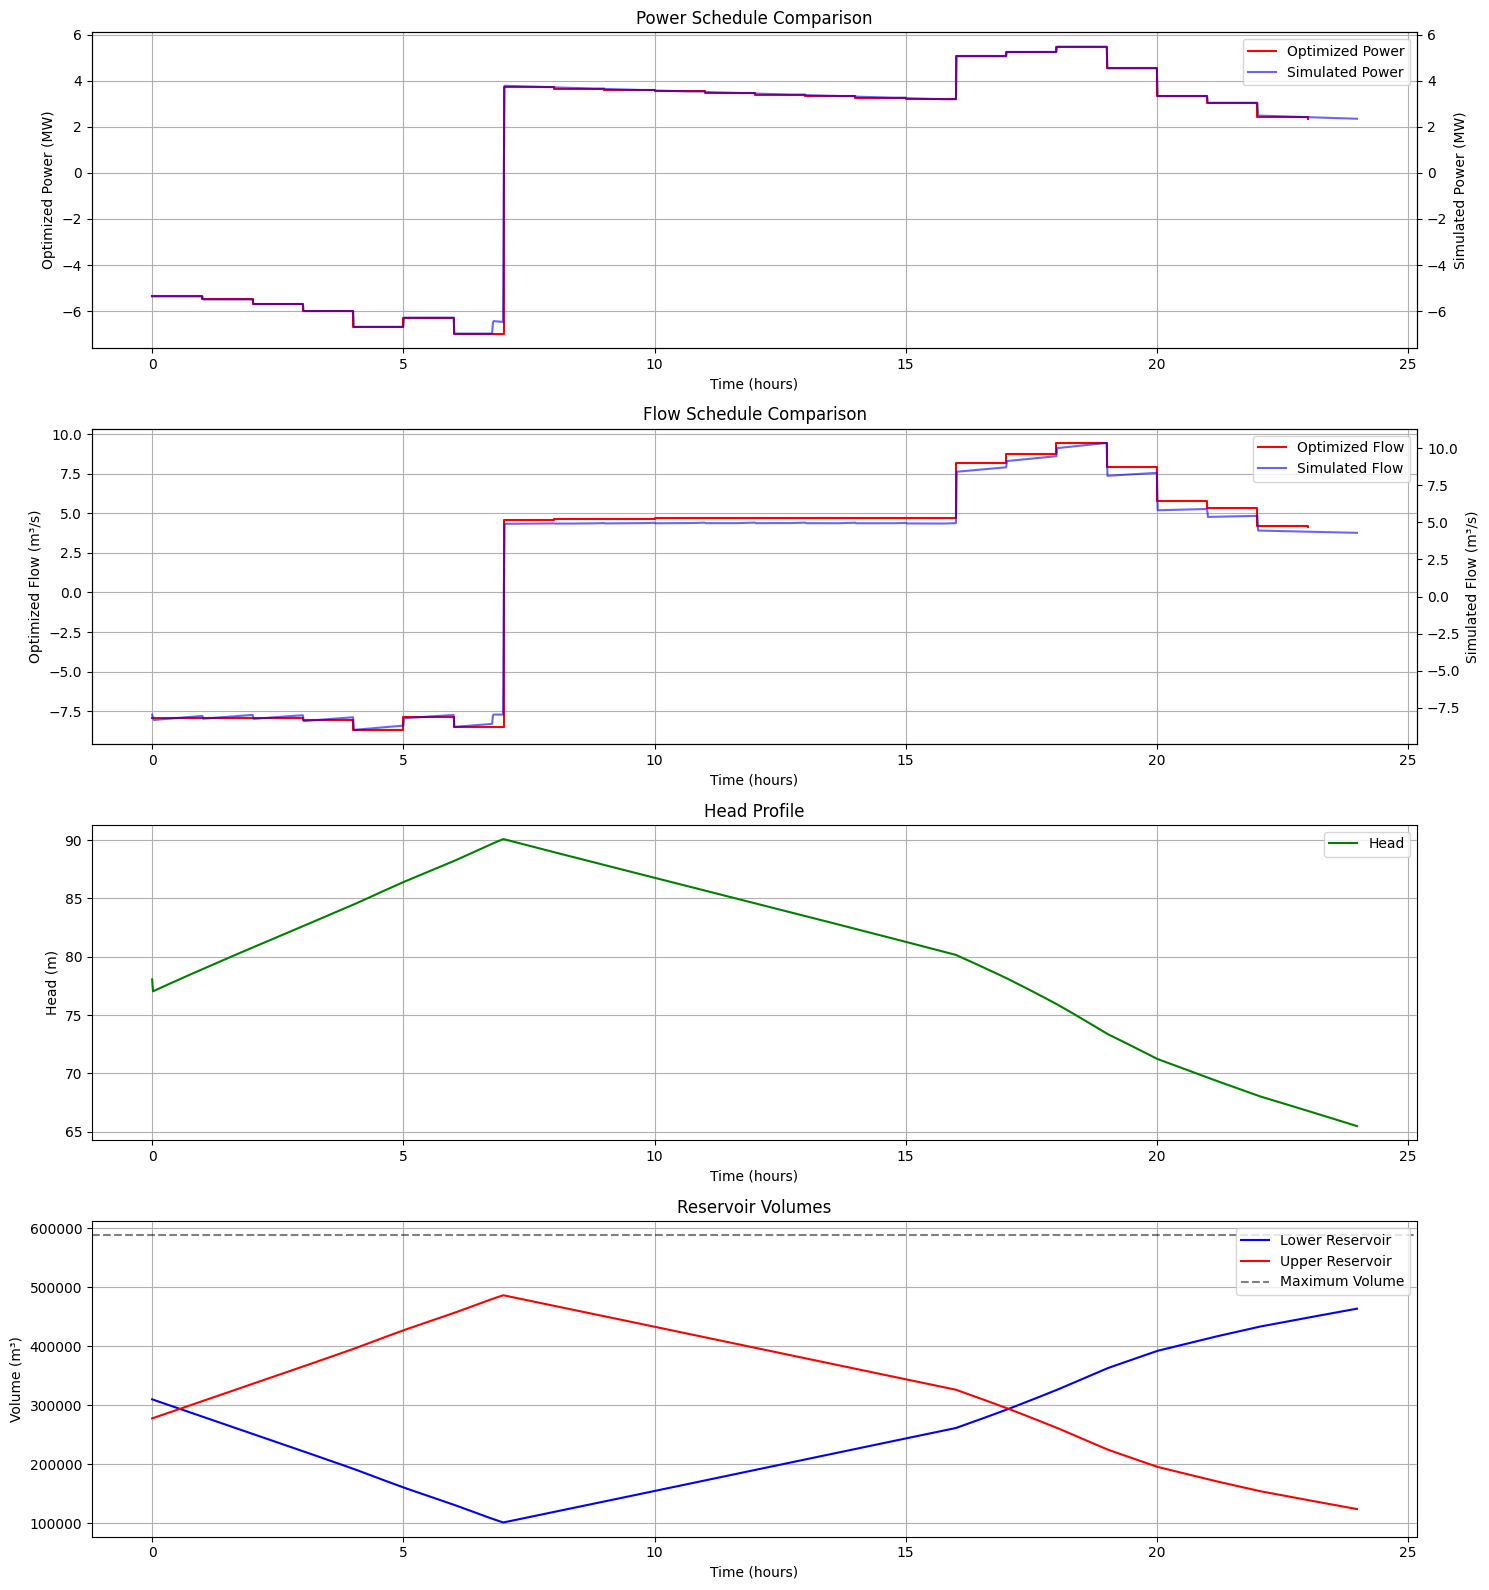

Optimized Power Schedule:
[-5.362693  -5.4935927 -5.69336   -6.0001736 -6.6822863 -6.2840266
 -6.9769197  3.7188387  3.6561153  3.5924108  3.5276845  3.4618628
  3.395123   3.3277063  3.2595925  3.1905763  5.055491   5.24189
  5.4718432  4.5329943  3.3265254  3.0383213  2.41131    2.3446813]

Optimized Flow Schedule:
[-7.9579535 -7.8967133 -7.9154487 -8.064099  -8.676145  -7.8913302
 -8.4988985  4.5658007  4.616347   4.652589   4.6857014  4.711204
  4.719426   4.7064524  4.6877503  4.674775   8.158248   8.71726
  9.439173   7.9489965  5.7926207  5.3387628  4.173081   4.1061587]

Optimized Head Schedule:
[78.058716 77.032745 77.06592  ... 65.510345 65.48782  65.46529 ]

Optimized Lower Reservoir Volume Schedule:
[310162.47 309673.   309174.2  ... 463324.97 463582.56 463840.2 ]

Profit:
tensor(63585.2500, grad_fn=<SubBackward0>)


In [14]:
def plot_optimization_simulation_results(p_opt, q_opt, p_sim_clb, q_sim_clb, h_sim_clb, v_low_clb, max_vol_low=max_vol_low, save_path="optimization_simulation_results.svg"):
    """
    Plot optimization and simulation results comparison with upper reservoir volume and save as SVG
   
    Args:
        p_opt (torch.Tensor): Optimized power schedule (hourly, size=24)
        q_opt (torch.Tensor): Optimized flow schedule (hourly, size=24)
        p_sim_clb (torch.Tensor): Simulated power schedule (per minute, size=1440)
        q_sim_clb (torch.Tensor): Simulated flow schedule (per minute, size=1440)
        h_sim_clb (torch.Tensor): Simulated head schedule (per minute, size=1440)
        v_low_clb (torch.Tensor): Simulated lower reservoir volume (per minute, size=1440)
        max_vol_low (float): Maximum volume of reservoirs (default=588000)
        save_path (str): Path where to save the SVG file (default="optimization_simulation_results.svg")
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from pathlib import Path
   
    # Create figure with 4 subplots (added one for better separation of volumes)
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 16))
   
    # Create time arrays
    t_hours = np.arange(24)
    t_minutes = np.arange(len(p_sim_clb)) / 60  # Convert to hours

    # Calculate upper reservoir volume
    v_up_clb = max_vol_low - v_low_clb.detach().numpy()
    
    # Plot 1: Power comparison
    ax1_opt = ax1
    ax1_sim = ax1.twinx()
   
    # Plot optimization results
    line1 = ax1_opt.step(t_hours, p_opt.detach().numpy(), 'r-', label='Optimized Power', where='post')
    # Plot simulation results
    line2 = ax1_sim.plot(t_minutes, p_sim_clb.detach().numpy(), 'b-', alpha=0.6, label='Simulated Power')
   
    # Add labels and legend
    ax1_opt.set_xlabel('Time (hours)')
    ax1_opt.set_ylabel('Optimized Power (MW)')
    ax1_sim.set_ylabel('Simulated Power (MW)')
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right')
    ax1.set_title('Power Schedule Comparison')
    ax1.grid(True)

    # Plot 2: Flow comparison
    ax2_opt = ax2
    ax2_sim = ax2.twinx()
   
    # Plot optimization results
    line3 = ax2_opt.step(t_hours, q_opt.detach().numpy(), 'r-', label='Optimized Flow', where='post')
    # Plot simulation results
    line4 = ax2_sim.plot(t_minutes, q_sim_clb.detach().numpy(), 'b-', alpha=0.6, label='Simulated Flow')
   
    # Add labels and legend
    ax2_opt.set_xlabel('Time (hours)')
    ax2_opt.set_ylabel('Optimized Flow (m³/s)')
    ax2_sim.set_ylabel('Simulated Flow (m³/s)')
    lines = line3 + line4
    labels = [l.get_label() for l in lines]
    ax2.legend(lines, labels, loc='upper right')
    ax2.set_title('Flow Schedule Comparison')
    ax2.grid(True)

    # Plot 3: Head
    # Plot head with single y-axis
    line5 = ax3.plot(t_minutes, h_sim_clb.detach().numpy(), 'g-', label='Head')
   
    # Add labels and legend
    ax3.set_xlabel('Time (hours)')
    ax3.set_ylabel('Head (m)')
    ax3.legend(loc='upper right')
    ax3.set_title('Head Profile')
    ax3.grid(True)

    # Plot 4: Reservoir Volumes
    # Create a shared axis for both volumes
    line6 = ax4.plot(t_minutes, v_low_clb.detach().numpy(), 'b-', label='Lower Reservoir')
    line7 = ax4.plot(t_minutes, v_up_clb, 'r-', label='Upper Reservoir')
    
    # Add horizontal line for maximum volume
    ax4.axhline(y=max_vol_low, color='k', linestyle='--', alpha=0.5, label='Maximum Volume')
    
    # Add labels and legend
    ax4.set_xlabel('Time (hours)')
    ax4.set_ylabel('Volume (m³)')
    ax4.legend(loc='upper right')
    ax4.set_title('Reservoir Volumes')
    ax4.grid(True)

    # Adjust layout to prevent overlap
    plt.tight_layout()
    
    # Save the figure as SVG
    # Ensure the directory exists
    save_dir = Path(save_path).parent
    save_dir.mkdir(parents=True, exist_ok=True)
    
    # Save with high DPI and vector format
    plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')
    print(f"Plot saved as: {save_path}")
    
    # Display the plot
    plt.show()
    
    # Close the figure to free memory
    plt.close(fig)

plot_optimization_simulation_results(p_opt, q_opt, p_sim_clb, q_sim_clb, h_sim_clb, v_low_clb)

# %%
# print optimal power, flow, head, and volume
print("Optimized Power Schedule:")
print(p_opt.detach().numpy())
print("\nOptimized Flow Schedule:")
print(q_opt.detach().numpy())
print("\nOptimized Head Schedule:")
print(h_sim_clb.detach().numpy())
print("\nOptimized Lower Reservoir Volume Schedule:")
print(v_low_clb.detach().numpy())
print("\nProfit:")
print(profit)

# Training and visualization

In [ ]:
import torch.optim as optim  
from datetime import datetime, timedelta
import random

def generate_random_dates_2022():
    """
    Generate 10 random dates from 2022 in "YYYY-MM-DD" format
    """
    start_date = datetime(2022, 1, 1)
    end_date = datetime(2022, 12, 31)
    
    date_range = (end_date - start_date).days + 1
    random_days = random.sample(range(date_range), 10)
    
    random_dates = [
        (start_date + timedelta(days=day)).strftime("%Y-%m-%d") 
        for day in random_days
    ]
    return random_dates


def train_weights(pipeline, num_epochs=100, learning_rate=0.001):
    """
    Train the weight prediction network using 10 random days from 2022
    """
    # Set random seed for reproducibility
    torch.manual_seed(42)
    random.seed(42)
    
    # Initialize optimizer for the weight network
    optimizer = optim.Adam(pipeline.weight_network.parameters(), lr=learning_rate)  # Using torch.optim
    
    # Generate 10 random dates from 2022
    training_dates = generate_random_dates_2022()
    
    # Lists to track metrics
    epoch_losses = []
    daily_profits = {date: [] for date in training_dates}
    
    # Create progress bar for epochs
    epoch_pbar = trange(num_epochs, desc='Training Progress')
    
    # Training loop
    for epoch in epoch_pbar:
        epoch_loss = 0
        
        # Iterate over each day with progress bar
        day_pbar = tqdm(training_dates, desc=f'Epoch {epoch+1}', leave=False)
        for date in day_pbar:
            # Read day-ahead prices for this date
            DA_price_hour = read_da_price(date)
            DA_price_quarter = hourly_to_quarterly(DA_price_hour)
            
            optimizer.zero_grad() # Zero the gradients
            
            # Forward pass through pipeline
            profit, p_opt, q_opt, h_opt, p_sim_clb, q_sim_clb, h_sim_clb, v_low_clb, c, d, e, a, b, w_p, w_q, w_h = pipeline.forward(
                power, head, DA_price_hour, DA_price_quarter
            )
            
            loss = -profit # Loss is negative profit (since we want to maximize profit)
            loss.backward() # Backward pass
            optimizer.step() # Update weights
            
            # Track metrics
            current_loss = loss.item()
            epoch_loss += current_loss
            daily_profits[date].append(profit.item())
            
            # Update day progress bar
            day_pbar.set_postfix({'Loss': f'{current_loss:.2f}'})
        
        # Average loss for this epoch
        avg_epoch_loss = epoch_loss / len(training_dates)
        epoch_losses.append(avg_epoch_loss)
        
        # Update epoch progress bar
        epoch_pbar.set_postfix({'Avg Loss': f'{avg_epoch_loss:.2f}'})
        
        # Sample weights display every 10 epochs
        if (epoch + 1) % 10 == 0:
            with torch.no_grad():
                sample_weights = pipeline.predict_weights(
                    DA_price_hour, power, flow, head
                )
                tqdm.write(f"\nEpoch {epoch+1} sample weights at t=0:"
                          f" w_p={sample_weights[0][0]:.4f},"
                          f" w_q={sample_weights[1][0]:.4f},"
                          f" w_h={sample_weights[2][0]:.4f}")
    
    return {
        'epoch_losses': epoch_losses,
        'daily_profits': daily_profits,
        'training_dates': training_dates
    }

def plot_training_results(training_results):
    """
    Plot training metrics
    """
    import matplotlib.pyplot as plt
    
    # Plot 1: Loss curve
    plt.figure(figsize=(10, 5))
    plt.plot(training_results['epoch_losses'])
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Average Loss')
    plt.grid(True)
    plt.show()
    
    # Plot 2: Daily profits
    plt.figure(figsize=(12, 6))
    for date in training_results['training_dates']:
        plt.plot(training_results['daily_profits'][date], label=date)
    plt.title('Daily Profits over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Profit')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example usage:
if __name__ == "__main__":
    # Initialize parameters and pipeline
    params = HydroParameters()
    pipeline = Pipeline(params)
    
    # Train the weights
    training_results = train_weights(pipeline, num_epochs=100)
    
    # Plot results
    plot_training_results(training_results)

Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]